## Simulating multiple datasets in parallel for parameter recovery

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.nn import sigmoid
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
from fastprogress import progress_bar
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm
from functools import partial
from jaxtyping import Float, Array


from jax import vmap, lax

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

from hmfc.model import HierarchicalBernoulliLDS
from hmfc.gibbs import gibbs_step  
from hmfc.utils import convert_mean_to_std_ig_params
from hmfc.constants import A_MAX

In [2]:
def simulate_one_dataset(key):

    # Sample inputs
    inputs = tfd.Normal(0, 1.0).sample(sample_shape=(num_subjects, num_trials, num_inputs), seed=key)

    # REQUIRE THAT INPUTS ARE MEAN ZERO
    inputs -= inputs.mean(axis=0)

    # Sample true params, states, and emissions
    true_params, true_states, emissions = true_model.sample(key, inputs)
    masks = jnp.ones_like(emissions)

    """
    Make sure we sample reasonable trajectories (not too extreme values, but also not just random noise)
    """
    crit_value_extreme = 9 # absolute max
    crit_value_fluct = 3 # difference between min and max should be at least 3
    max_iter = 75

    too_extreme = jnp.where(jnp.max(jnp.abs(true_states),axis=1) > crit_value_extreme)[0]
    no_fluctuations = jnp.where(jnp.max(true_states, axis=1) - jnp.min(true_states, axis=1) < crit_value_fluct)[0]

    bad_subjects = jnp.concatenate([too_extreme,no_fluctuations])
    seed = 0 # resampling seed
    
    if bad_subjects.size > 0:
        for subj in bad_subjects:
            print(subj)
            
            # Call the true params and input from bad subject
            x_it = true_states[subj]
            u_i = inputs[subj]

            w_i = true_params['w'][subj]
            a_i = true_params['a'][subj]
            sigmasq_i = true_params['sigmasq'][subj]
            mu_x_i = true_params['mu_x'][subj]

            # Resample true_states and emissions from true params and inputs
            iter = 0
            while ((jnp.any(jnp.abs(x_it) > crit_value_extreme)) or ((jnp.max(x_it) - jnp.min(x_it)) < crit_value_fluct)):
  
                key = jr.PRNGKey(0)
                k1, k2, k3 = jr.split(key,3)

                # Sample latent states
                b_i = mu_x_i * (1 - a_i)
                sigmasq0_i = 1
                
                x_it0 = tfd.Normal(mu_x_i, jnp.sqrt(sigmasq0_i)).sample(seed=k1)
                def _step(x_itp, key):
                    x_itp1 = tfd.Normal(a_i * x_itp + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
                    return x_itp1, x_itp
                _, x_it = lax.scan(_step, x_it0, jr.split(k2, num_trials))

                # Sample emissions
                y_it = tfd.Bernoulli(x_it + u_i @ w_i).sample(seed=k3)

                iter=iter+1

                if iter == max_iter: # if stuck in a loop, resample parameters
                    
                    key = jr.PRNGKey(seed)
                    k1, k2, k3 = jr.split(key,3)
                    # sample new params
                    print('new params sampled!')
                    a_i = tfd.TruncatedNormal(true_mu_a,
                                              true_sigma_a,
                                              0.0, A_MAX).sample(seed=k1)

                    sigmasq_i = tfd.InverseGamma(*convert_mean_to_std_ig_params(true_mu_sigmasq, true_beta_sigmasq)).sample(seed=k2)

                    mu_x_i = tfd.Normal(0, true_sigma_mu_x).sample(seed=k3)

                    # save new params
                    true_params['a'] = true_params['a'].at[subj].set(a_i)
                    true_params['sigmasq'] = true_params['sigmasq'].at[subj].set(sigmasq_i)
                    true_params['mu_x'] = true_params['mu_x'].at[subj].set(mu_x_i)

                    # change seed such that if we resample the parameter are not the same
                    seed=seed+1
                    iter = 0 

            # Save new true_states and emissions

            true_states = true_states.at[subj].set(x_it)
            emissions = emissions.at[subj].set(y_it)


    return true_params, true_states, emissions, inputs, masks



In [3]:
def fit_model(key, emissions, inputs, masks):
    
    key = jr.PRNGKey(key) if isinstance(key, int) else key

    # Initialize model
    model = HierarchicalBernoulliLDS(num_inputs,
                                     mu_a=init_mu_a, 
                                     sigma_a=init_sigma_a, 
                                     mu_w=init_mu_w, 
                                     sigma_w=init_sigma_w, 
                                     mu_sigmasq=init_mu_sigmasq,
                                     beta_sigmasq=init_beta_sigmasq, 
                                     sigma_mu_x=init_sigma_mu_x)
    
    params, states, _ = model.sample(key, inputs)

    # Fit model
    lps = jnp.zeros((num_iters,)) # log probability
    
    posterior_samples_mu_a = jnp.zeros((num_iters,))
    posterior_samples_sigma_a = jnp.zeros((num_iters,))
    posterior_samples_mu_w = jnp.zeros((num_iters, num_inputs))
    posterior_samples_sigma_w = jnp.zeros((num_iters, num_inputs))
    posterior_samples_mu_sigmasq = jnp.zeros((num_iters,))
    posterior_samples_beta_sigmasq = jnp.zeros((num_iters,))
    posterior_samples_sigma_mu_x = jnp.zeros((num_iters,))
    
    posterior_samples_a = jnp.zeros((num_iters, num_subjects))
    posterior_samples_sigmasq = jnp.zeros((num_iters, num_subjects))
    posterior_samples_w = jnp.zeros((num_iters, num_subjects, num_inputs))
    posterior_samples_mu_x = jnp.zeros((num_iters, num_subjects))
    
    posterior_samples_states = jnp.zeros((num_iters, num_subjects, num_trials))
    
    for itr in progress_bar(range(num_iters)):
    
        this_key, key = jr.split(key)
        lp, states, params, model = gibbs_step(this_key, emissions, masks, states, inputs, params, model, update_global_weights=True, update_global_weights_var=True, update_global_bias_var=True, update_global_ar=True, update_global_ar_var=True, update_global_mu_sigmasq=True, update_global_beta_sigmasq=True)
    
        lps = lps.at[itr].set(lp)
    
        posterior_samples_mu_a = posterior_samples_mu_a.at[itr].set(sigmoid(model.logit_mu_a))
        posterior_samples_sigma_a = posterior_samples_sigma_a.at[itr].set(jnp.exp(model.log_sigma_a))
        posterior_samples_mu_w = posterior_samples_mu_w.at[itr].set(model.mu_w)
        posterior_samples_sigma_w = posterior_samples_sigma_w.at[itr].set(jnp.exp(model.log_sigma_w))
        posterior_samples_mu_sigmasq = posterior_samples_mu_sigmasq.at[itr].set(jnp.exp(model.log_mu_sigmasq))
        posterior_samples_beta_sigmasq = posterior_samples_beta_sigmasq.at[itr].set(jnp.exp(model.log_beta_sigmasq))
        posterior_samples_sigma_mu_x = posterior_samples_sigma_mu_x.at[itr].set(jnp.exp(model.log_sigma_mu_x))
    
        posterior_samples_a = posterior_samples_a.at[itr].set(params['a'])
        posterior_samples_sigmasq = posterior_samples_sigmasq.at[itr].set(params['sigmasq'])
        posterior_samples_w = posterior_samples_w.at[itr].set(params['w'])
        posterior_samples_mu_x = posterior_samples_mu_x.at[itr].set(params['mu_x'])
    
        posterior_samples_states = posterior_samples_states.at[itr].set(states)

    return emissions, inputs, lps, posterior_samples_mu_a, posterior_samples_sigma_a, posterior_samples_mu_w, posterior_samples_sigma_w, posterior_samples_mu_sigmasq, posterior_samples_beta_sigmasq, posterior_samples_sigma_mu_x, posterior_samples_a, posterior_samples_sigmasq, posterior_samples_w, posterior_samples_mu_x, posterior_samples_states  




## Simulate from the model

In [4]:
num_subjects = 50
num_trials = 500
num_iters = 1500
num_inputs = 3
num_datasets = 5

true_mu_a = 0.98
true_sigma_a = 0.03
true_mu_w = jnp.array([0.0, 0.2, -0.1])
true_sigma_w = jnp.array([1.0, 1.0, 1.0])

true_mu_sigmasq = 0.2
true_beta_sigmasq = 0.5
true_sigma_mu_x = 0.5

# Create our true model
true_model = HierarchicalBernoulliLDS(num_inputs,
                                      mu_a=true_mu_a, 
                                      sigma_a=true_sigma_a, 
                                      mu_w=true_mu_w, 
                                      sigma_w=true_sigma_w, 
                                      mu_sigmasq=true_mu_sigmasq,
                                      beta_sigmasq=true_beta_sigmasq, 
                                      sigma_mu_x=true_sigma_mu_x)

In [5]:
all_true_params, all_true_states, all_emissions, all_inputs, all_masks = [],[],[],[],[]

# if vmap this thing then use lax.cond for resampling bad subjects (see simulate_one_dataset)
for dataset in jnp.arange(num_datasets):
    print("Dataset",dataset)
    true_params, true_states, emissions, inputs, masks = simulate_one_dataset(jr.PRNGKey(dataset))
    all_true_params.append(true_params)
    all_true_states.append(true_states)
    all_emissions.append(emissions)
    all_inputs.append(inputs)
    all_masks.append(masks)

all_emissions = jnp.stack(all_emissions)
all_inputs = jnp.stack(all_inputs)
all_masks = jnp.stack(all_masks)

Dataset 0
13
25
new params sampled!
Dataset 1
25
33
new params sampled!
39
new params sampled!
Dataset 2
0
1
new params sampled!
7
Dataset 3
45
new params sampled!
Dataset 4
17


In [6]:
# Initialize model
init_mu_a = 0.9
init_sigma_a = 0.1
init_mu_w = jnp.zeros(num_inputs)
init_sigma_w = jnp.repeat(1e4, num_inputs)
init_mu_sigmasq = 0.2
init_beta_sigmasq = 0.5
init_sigma_mu_x = 5.0

## Fit model


In [7]:
keys = jr.split(jr.PRNGKey(0), num_datasets)
emissions, inputs, lps, posterior_samples_mu_a, posterior_samples_sigma_a, posterior_samples_mu_w, posterior_samples_sigma_w, posterior_samples_mu_sigmasq, posterior_samples_beta_sigmasq, posterior_samples_sigma_mu_x, posterior_samples_a, posterior_samples_sigmasq, posterior_samples_w, posterior_samples_mu_x, posterior_samples_states = vmap(fit_model)(keys, all_emissions, all_inputs, all_masks)

## Log prob


In [8]:
dataset = 2
burn_in = 500

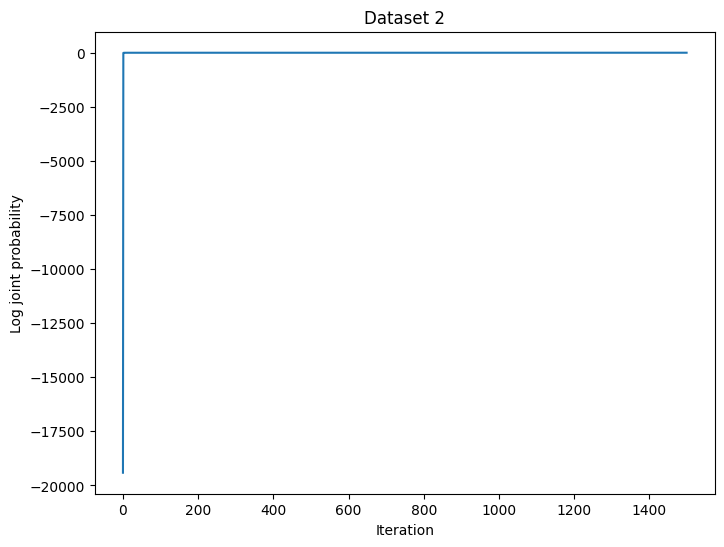

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(jnp.stack(lps[dataset])/emissions[dataset].size) # normalized log joint prob
plt.title(r"Dataset {:d}".format(dataset))
plt.xlabel("Iteration")
plt.ylabel("Log joint probability")
plt.show()

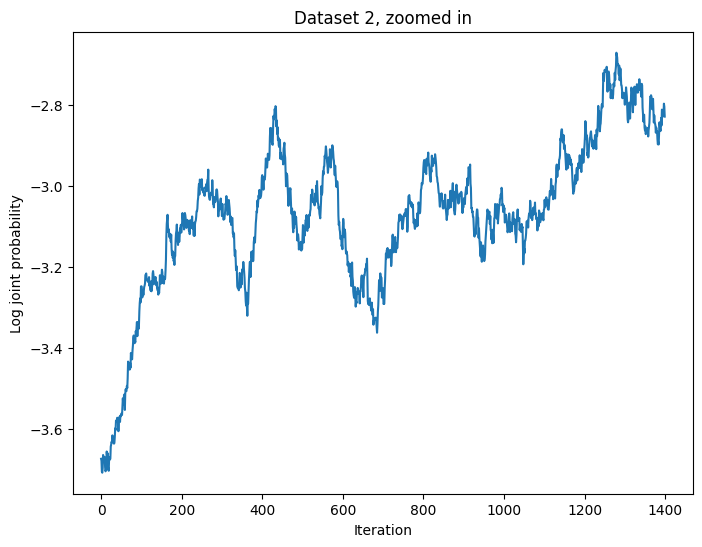

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(jnp.stack(lps[dataset, 100:])/emissions[dataset].size) # normalized log joint prob
plt.title(r"Dataset {:d}, zoomed in".format(dataset))
plt.xlabel("Iteration")
plt.ylabel("Log joint probability")
plt.show()

## Estimated criterion fluctuations

### Example subject

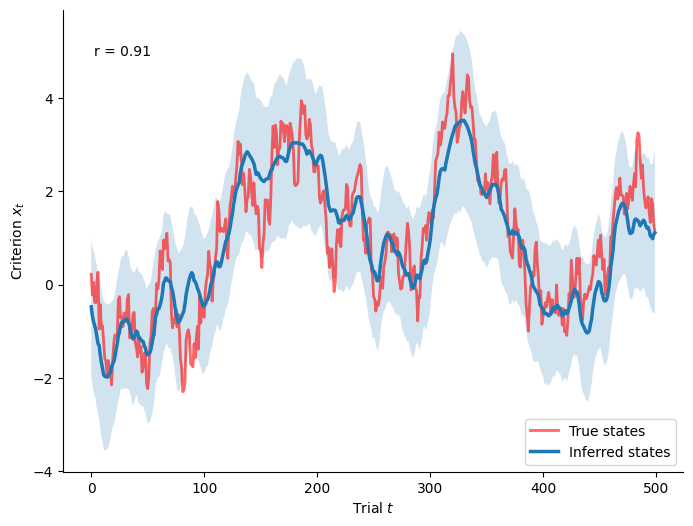

In [41]:
dataset = 2
subject = 6

posterior_states_mean = jnp.mean(posterior_samples_states[dataset,burn_in:,subject,:], axis=0)
posterior_states_sd = jnp.std(posterior_samples_states[dataset,burn_in:,subject,:], axis=0)

plt.figure(figsize=(8, 6))
plt.plot(all_true_states[dataset][subject], label="True states", linewidth=2, color='red', alpha=.6)
plt.plot(posterior_states_mean, label="Inferred states", linewidth=2.5)
plt.fill_between(jnp.arange(num_trials),
          posterior_states_mean - 2 * posterior_states_sd,
          posterior_states_mean + 2 * posterior_states_sd, alpha=0.2)
plt.xlabel("Trial $t$")
plt.ylabel("Criterion $x_t$")
#plt.ylim(-7.5,7.5)
plt.legend(loc='lower right')
r, p = spearmanr(all_true_states[dataset][subject], posterior_states_mean)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')
sns.despine()
plt.show()

### All subjects in one dataset

In [12]:
dataset=0

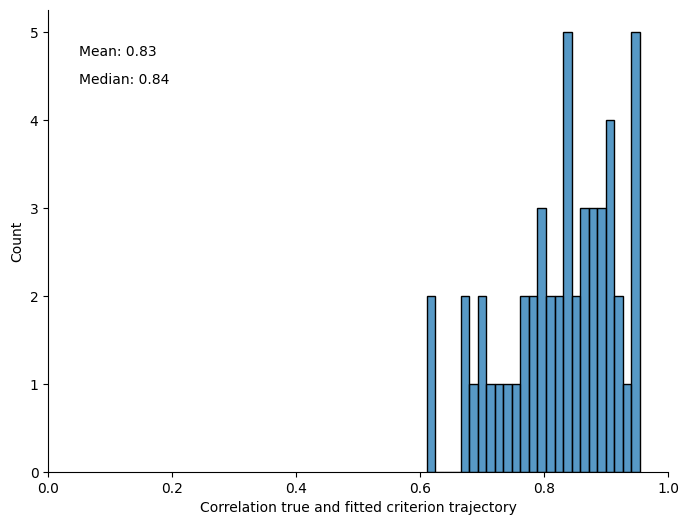

In [13]:
correlations_inferred_and_fitted_states = []

for subject in range(num_subjects):
    r, _= spearmanr(all_true_states[dataset][subject], jnp.mean(posterior_samples_states[dataset,burn_in:,subject,:], axis=0))
    correlations_inferred_and_fitted_states.append(r)

correlations_inferred_and_fitted_states = jnp.array(correlations_inferred_and_fitted_states)

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)

plt.figure(figsize=(8, 6))
sns.histplot(data=correlations_inferred_and_fitted_states, bins=25)
plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction')
plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.84), xycoords='axes fraction')
plt.xlabel('Correlation true and fitted criterion trajectory')
plt.ylabel('Count')
plt.xlim(0,1)
sns.despine()
plt.show()

# Per-subject parameters

## Compare true and inferred estimates of $a_i$

In [51]:
dataset = 4

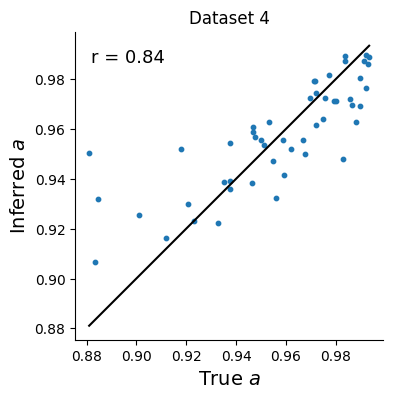

In [52]:
a_min = min(all_true_params[dataset]['a'].min(), jnp.mean(posterior_samples_a[dataset][burn_in:], axis=0).min())
a_max = max(all_true_params[dataset]['a'].max(), jnp.mean(posterior_samples_a[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(6, 4))
plt.scatter(all_true_params[dataset]['a'], jnp.mean(posterior_samples_a[dataset][burn_in:], axis=0), s=10)
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xlabel("True $a$", size=14)
plt.ylabel("Inferred $a$", size=14)
plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(all_true_params[dataset]['a'], jnp.mean(posterior_samples_a[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.9), xycoords='axes fraction', size=13)
sns.despine()
plt.savefig("a_priors.png", transparent=True, dpi=600)
        

## Compare true and inferred estimates of $\sigma^2_i$

In [57]:
dataset = 4

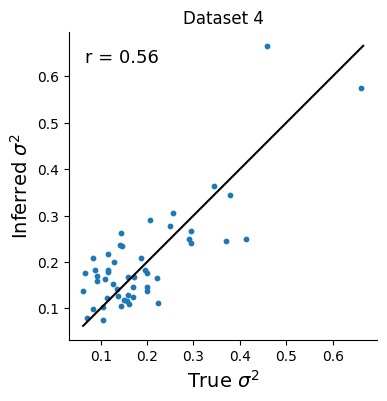

In [58]:
sigmasq_min = min(all_true_params[dataset]['sigmasq'].min(), jnp.mean(posterior_samples_sigmasq[dataset][burn_in:], axis=0).min())
sigmasq_max = max(all_true_params[dataset]['sigmasq'].max(), jnp.mean(posterior_samples_sigmasq[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(6, 4))
plt.scatter(all_true_params[dataset]['sigmasq'], jnp.mean(posterior_samples_sigmasq[dataset][burn_in:], axis=0), s=10)
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xlabel("True $\sigma^2$", size=14)
plt.ylabel("Inferred $\sigma^2$", size=14)
plt.title(r"Dataset {:d}".format(dataset))
# plt.ylim(0,10)
# plt.xlim(0,1)
plt.gca().set_aspect(1.0)
r, p = spearmanr(all_true_params[dataset]['sigmasq'], jnp.mean(posterior_samples_sigmasq[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.9), xycoords='axes fraction', size=13)
sns.despine()
plt.savefig("sigma_priors.png", transparent=True, dpi=600)


## Compare true and inferred estimates of $\mu_{0,i}$

In [59]:
dataset = 4

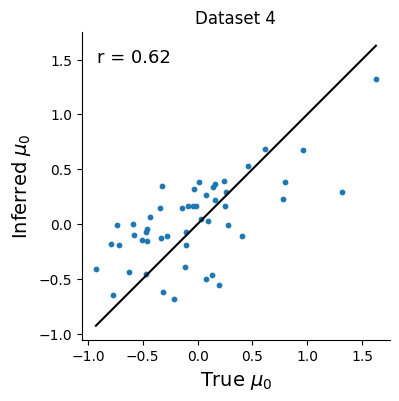

In [60]:
mu_x_min = min(all_true_params[dataset]['mu_x'].min(), jnp.mean(posterior_samples_mu_x[dataset][burn_in:], axis=0).min())
mu_x_max = max(all_true_params[dataset]['mu_x'].max(), jnp.mean(posterior_samples_mu_x[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(6, 4))
plt.scatter(all_true_params[dataset]['mu_x'], jnp.mean(posterior_samples_mu_x[dataset][burn_in:], axis=0), s=10)
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xlabel("True $\mu_0$", size=14)
plt.ylabel("Inferred $\mu_0$", size=14)
plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(all_true_params[dataset]['mu_x'], jnp.mean(posterior_samples_mu_x[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.9), xycoords='axes fraction', size=13)
sns.despine()
plt.savefig("mu_priors.png", transparent=True, dpi=600)

## Compare true and inferred estimates of $w_i$

In [21]:
dataset = 2

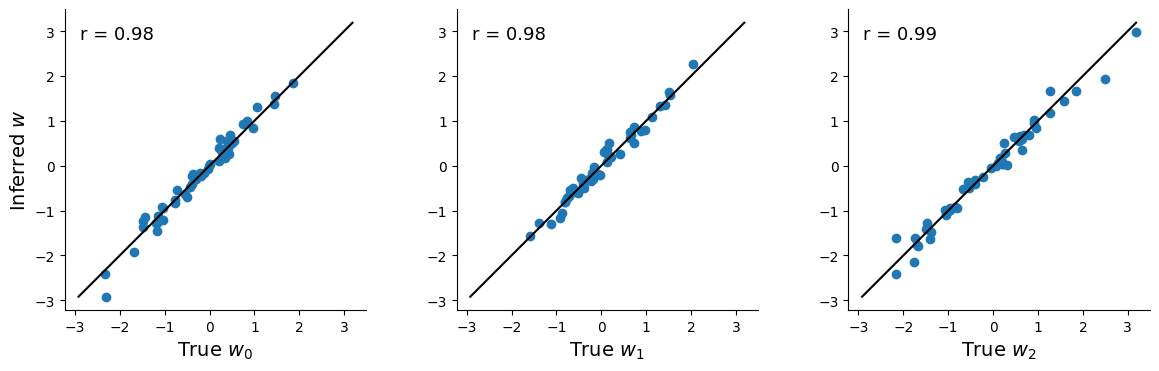

In [27]:
w_min = min(all_true_params[dataset]["w"].min(), jnp.mean(posterior_samples_w[dataset][burn_in:,:,:], axis=0).min())
w_max = max(all_true_params[dataset]["w"].max(), jnp.mean(posterior_samples_w[dataset][burn_in:,:,:], axis=0).max())

fig, axs = plt.subplots(1, num_inputs, sharey=False, figsize=(14, 4))

for d, ax in enumerate(axs):
    ax.scatter(all_true_params[dataset]["w"][:, d], jnp.mean(posterior_samples_w[dataset][burn_in:,:,d], axis=0))
    ax.set_xlabel(r"True $w_{:d}$".format(d), size=14)
    if d == 0:
        ax.set_ylabel(r"Inferred $w$", size=14)
    ax.plot([w_min, w_max], [w_min, w_max], '-k')
    ax.set_aspect(1.0)
    r, p = spearmanr(all_true_params[dataset]["w"][:, d], jnp.mean(posterior_samples_w[dataset][burn_in:,:,d], axis=0))
    ax.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.9), xycoords='axes fraction', size=13)
    sns.despine()

fig.subplots_adjust(wspace=0.3)
plt.show()

# Group-level parameters

## Compare true and estimated $\mu_w$

### Posterior

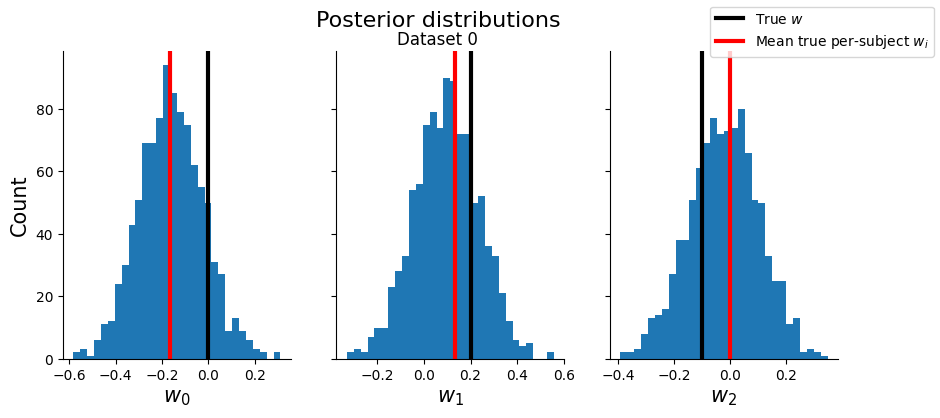

In [26]:
fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 4))
fig.suptitle("Posterior distributions", fontsize=16)
fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)

mean_true_per_subject_w = jnp.mean(all_true_params[dataset]['w'], axis=0)
for d, ax in enumerate(axs):
    ax.hist(posterior_samples_mu_w[dataset][burn_in:, d], bins=30)
    ax.axvline(x=true_mu_w[d], color='black', linewidth=3)
    ax.axvline(x=mean_true_per_subject_w[d], color='red', linewidth=3)
    
    if d == 0:
        ax.set_ylabel("Count", fontsize=15)
    ax.set_xlabel(r"$w_{:d}$".format(d), fontsize=15)
    
fig.legend([r"True $w$", r'Mean true per-subject $w_i$'])
sns.despine()
plt.show()

### Posterior over iterations

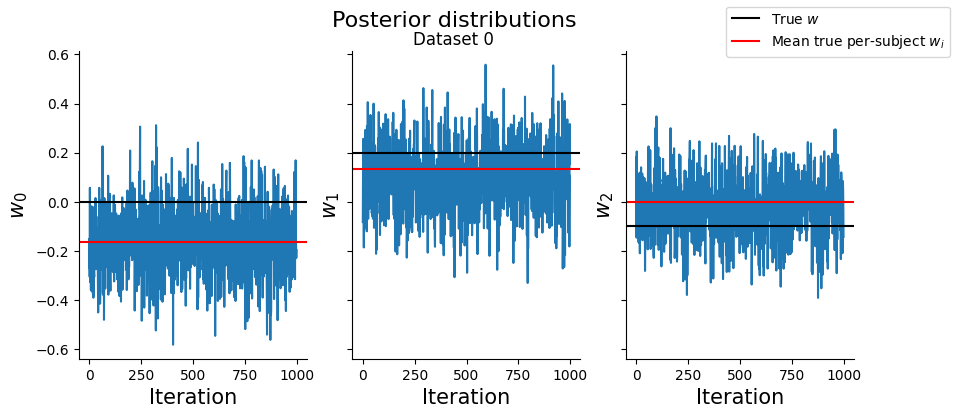

In [27]:
fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 4))
fig.suptitle("Posterior distributions", fontsize=16)
fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)

mean_true_per_subject_w = jnp.mean(all_true_params[dataset]['w'], axis=0)
for d, ax in enumerate(axs):
    ax.plot(posterior_samples_mu_w[dataset][burn_in:, d])
    ax.axhline(y=true_mu_w[d], color='black')
    ax.axhline(y=mean_true_per_subject_w[d], color='red')
    ax.set_xlabel("Iteration", fontsize=15)
    ax.set_ylabel(r"$w_{:d}$".format(d), fontsize=15)
    
fig.legend([Line2D([0], [0], color='black'), Line2D([0], [0], color='red')],[r"True $w$", r'Mean true per-subject $w_i$']) # fix to have black line in legend (without it is blue)
sns.despine()
plt.show()

## Compare true and estimated $\sigma_{\mu_w}$

### Posterior

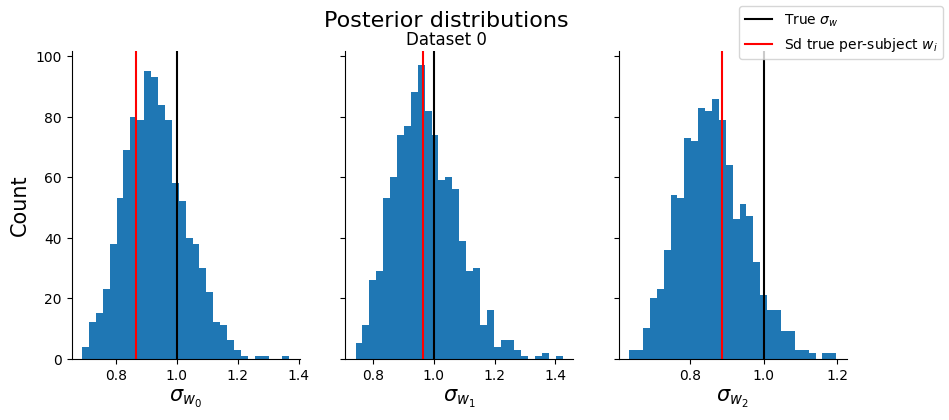

In [28]:
fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 4))
fig.suptitle("Posterior distributions", fontsize=16)
fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)

sd_true_per_subject_w = jnp.std(all_true_params[dataset]['w'], axis=0)
for d, ax in enumerate(axs):
    ax.hist(posterior_samples_sigma_w[dataset][burn_in:, d], bins=30)
    ax.axvline(x=true_sigma_w[d], color='black')
    ax.axvline(x=sd_true_per_subject_w[d], color='red')
    if d == 0:
        ax.set_ylabel("Count", fontsize=15)
    ax.set_xlabel(r"$\sigma_{{w_{:d}}}$".format(d), fontsize=15)

fig.legend([r"True $\sigma_w$", r'Sd true per-subject $w_i$'])
sns.despine()
plt.show()

### Posterior over iterations

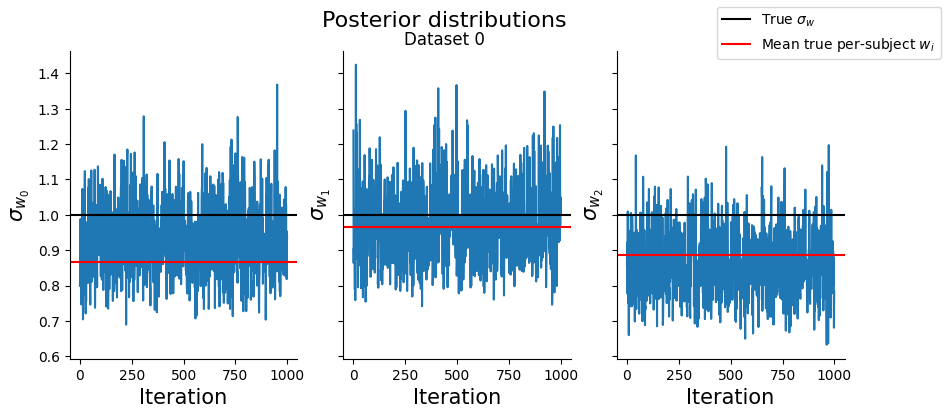

In [29]:
fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 4))
fig.suptitle("Posterior distributions", fontsize=16)
fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)

sd_true_per_subject_w = jnp.std(all_true_params[dataset]['w'], axis=0)
for d, ax in enumerate(axs):
    ax.plot(posterior_samples_sigma_w[dataset][burn_in:, d])
    ax.axhline(y=true_sigma_w[d], color='black')
    ax.axhline(y=sd_true_per_subject_w[d], color='red')
    ax.set_xlabel("Iteration", fontsize=15)
    ax.set_ylabel(r"$\sigma_{{w_{:d}}}$".format(d), fontsize=15)

fig.legend([Line2D([0], [0], color='black'), Line2D([0], [0], color='red')],[r"True $\sigma_w$", r'Mean true per-subject $w_i$']) # fix to have black line in legend (without it is blue)
sns.despine()
plt.show()

## Compare true and estimated $\mu_a$

### Posterior

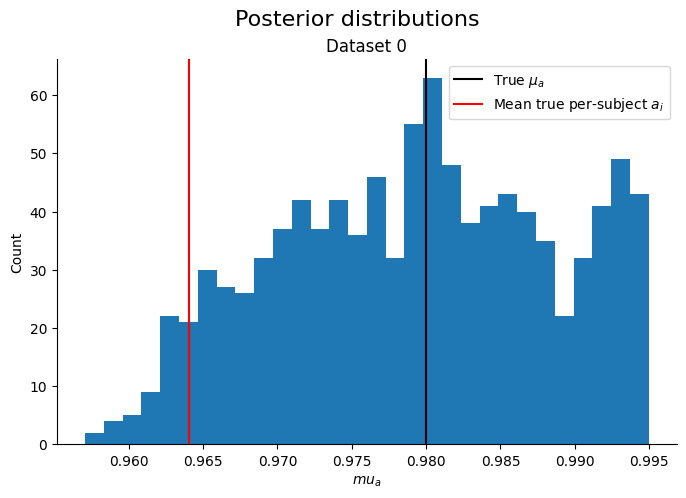

In [48]:
dataset = 0

plt.figure(figsize=(8, 5))
plt.hist(posterior_samples_mu_a[dataset][burn_in:], bins=30)
plt.axvline(true_mu_a, color='black', label="True $\mu_a$")
plt.axvline(jnp.mean(all_true_params[dataset]['a']), color='red', label="Mean true per-subject $a_i$")
plt.xlabel("$mu_a$")
plt.ylabel("Count")
plt.legend(loc='upper right')
plt.suptitle("Posterior distributions", fontsize=16)
plt.title("Dataset {:d}".format(dataset), fontsize=12)
sns.despine()
plt.show()

### Posterior over iterations

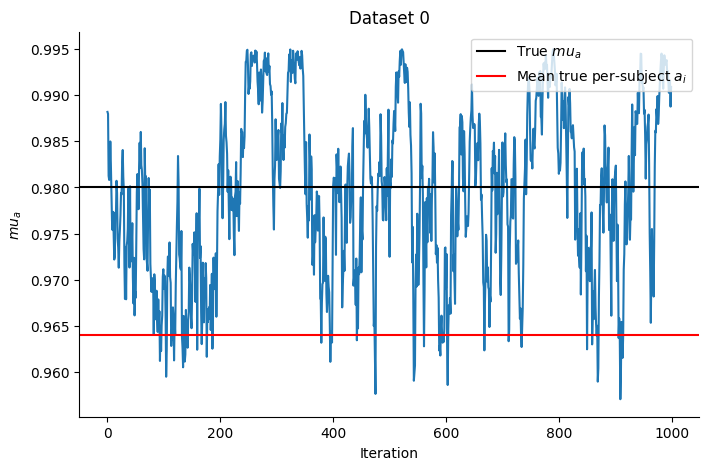

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(posterior_samples_mu_a[dataset][burn_in:])
plt.axhline(true_mu_a, color='black', label="True $mu_a$")
plt.axhline(jnp.mean(all_true_params[dataset]['a']), color='red', label="Mean true per-subject $a_i$")
plt.xlabel("Iteration")
plt.ylabel("$mu_a$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

## Compare true and estimated $\sigma_{mu_a}$

### Posterior

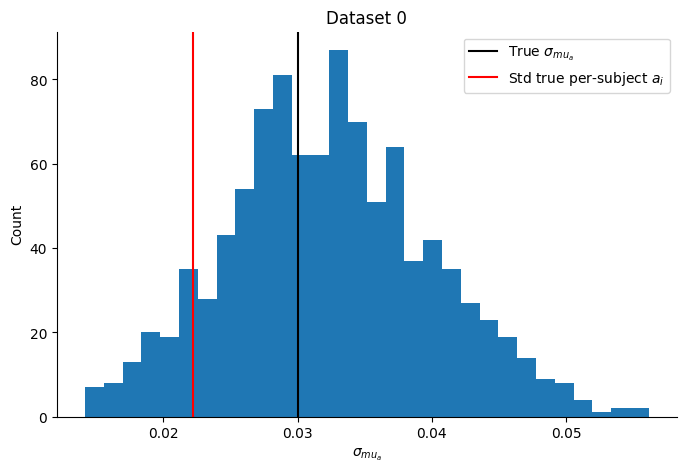

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(posterior_samples_sigma_a[dataset][burn_in:], bins=30)
plt.axvline(true_sigma_a, color='black', label=r"True $\sigma_{mu_a}$")
plt.axvline(jnp.std(all_true_params[dataset]['a']), color='red', label="Std true per-subject $a_i$")
plt.ylabel("Count")
plt.xlabel(r"$\sigma_{mu_a}$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

### Posterior over iterations

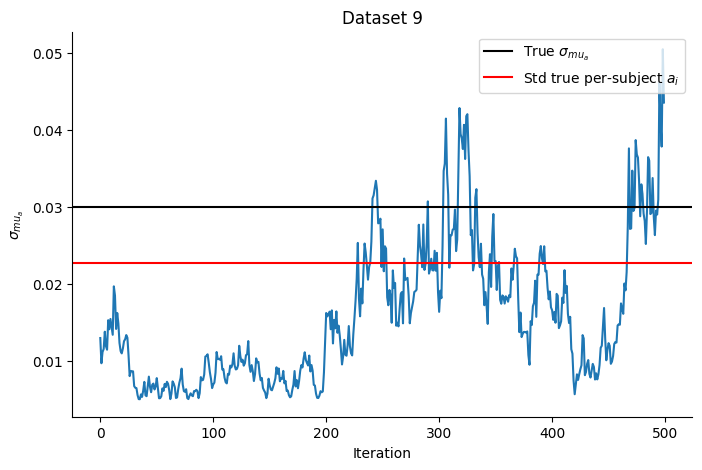

In [46]:
dataset = 9

plt.figure(figsize=(8, 5))
plt.plot(posterior_samples_sigma_a[dataset][burn_in:])
plt.axhline(true_sigma_a, color='black', label=r"True $\sigma_{mu_a}$")
plt.axhline(jnp.std(all_true_params[dataset]['a']), color='red', label="Std true per-subject $a_i$")
plt.xlabel("Iteration")
plt.ylabel(r"$\sigma_{mu_a}$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

## Compare true and estimated $\alpha$

### Posterior

In [34]:
dataset = 9

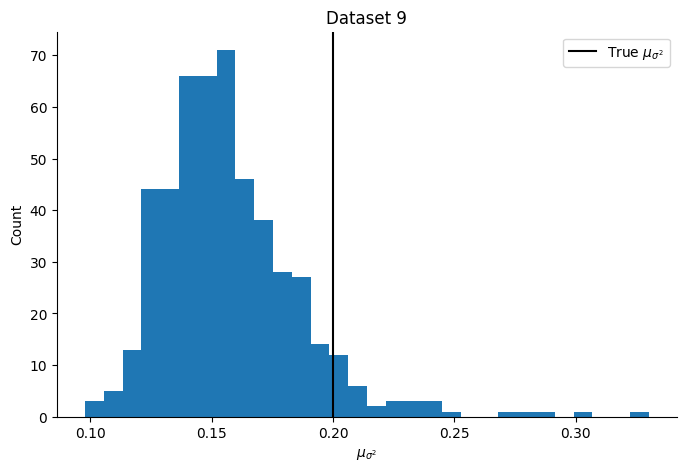

In [47]:
plt.figure(figsize=(8, 5))
plt.hist(posterior_samples_mu_sigmasq[dataset][burn_in:], bins=30)
plt.axvline(true_mu_sigmasq, color='black', label=r"True $\mu_{\sigma^2}$")
plt.ylabel("Count")
plt.xlabel(r"$\mu_{\sigma^2}$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

### Posterior over iterations

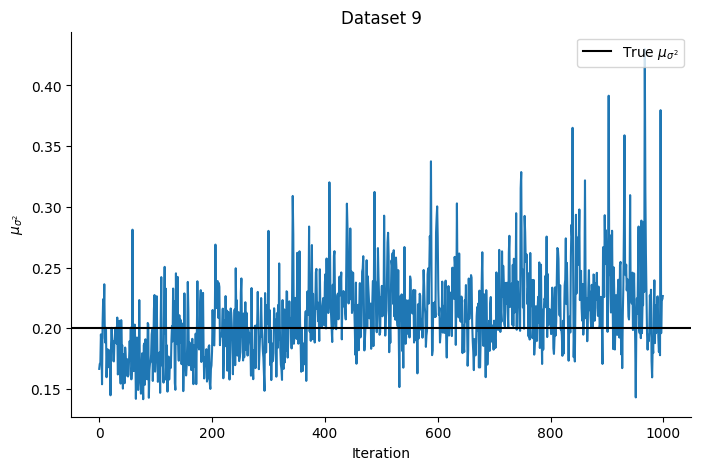

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(posterior_samples_mu_sigmasq[dataset][burn_in:])
plt.axhline(true_mu_sigmasq, color='black', label=r"True $\mu_{\sigma^2}$")
plt.xlabel("Iteration")
plt.ylabel(r"$\mu_{\sigma^2}$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

## Compare true and estimated $\beta$

### Posterior

In [134]:
dataset=8

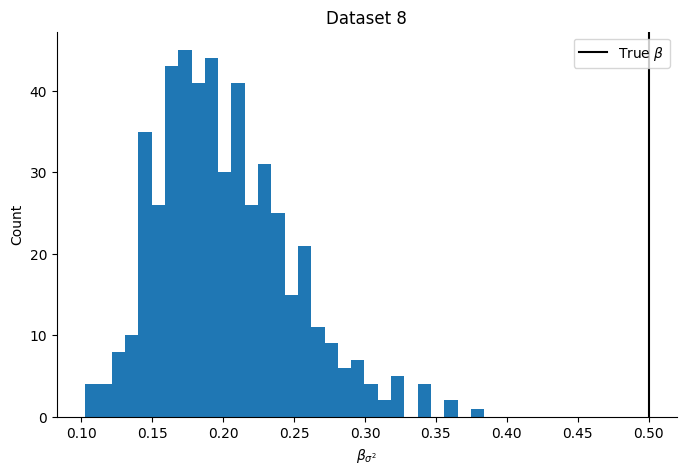

In [135]:
plt.figure(figsize=(8, 5))
plt.hist(posterior_samples_beta_sigmasq[dataset][burn_in:], bins=30)
plt.axvline(true_beta_sigmasq, color='black', label=r"True $\beta$")
plt.ylabel("Count")
plt.xlabel(r"$\beta_{\sigma^2}$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

### Posterior over iterations

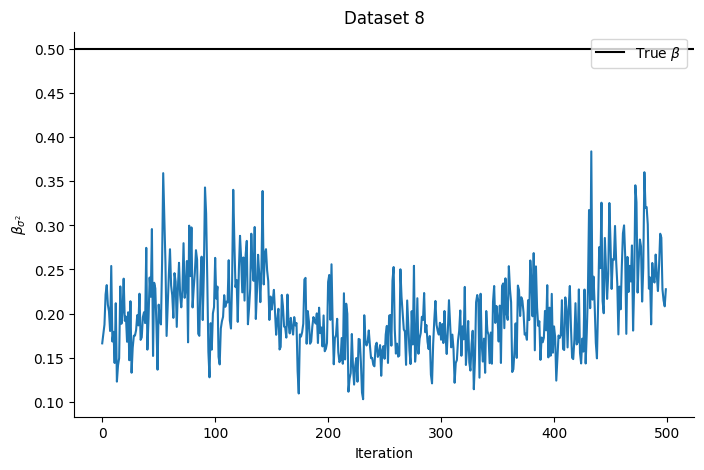

In [136]:
plt.figure(figsize=(8, 5))
plt.plot(posterior_samples_beta_sigmasq[dataset][burn_in:])
plt.axhline(true_beta_sigmasq, color='black', label=r"True $\beta$")
plt.xlabel("Iteration")
plt.ylabel(r"$\beta_{\sigma^2}$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

## Compare true and estimate $\sigma_{\mu_0}$

### Posterior

In [40]:
dataset=0

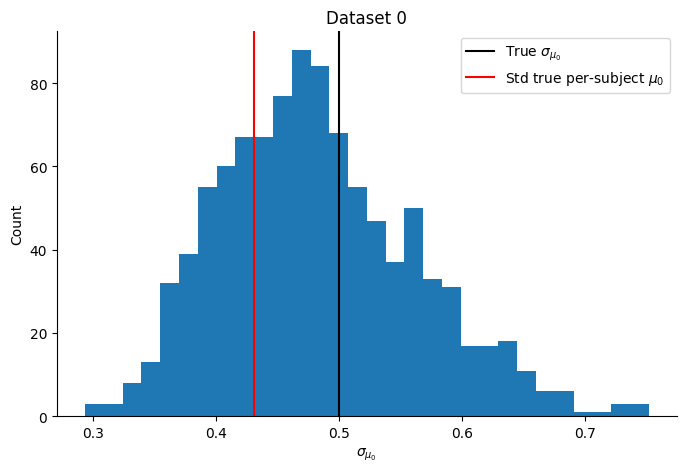

In [41]:
plt.figure(figsize=(8, 5))
plt.hist(posterior_samples_sigma_mu_x[dataset][burn_in:], bins=30)
plt.axvline(true_sigma_mu_x, color='black', label=r"True $\sigma_{\mu_0}$")
plt.axvline(jnp.std(all_true_params[dataset]['mu_x']), color='red', label="Std true per-subject $\mu_0$")
plt.ylabel("Count")
plt.xlabel(r"$\sigma_{\mu_0}$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

### Posterior over iterations

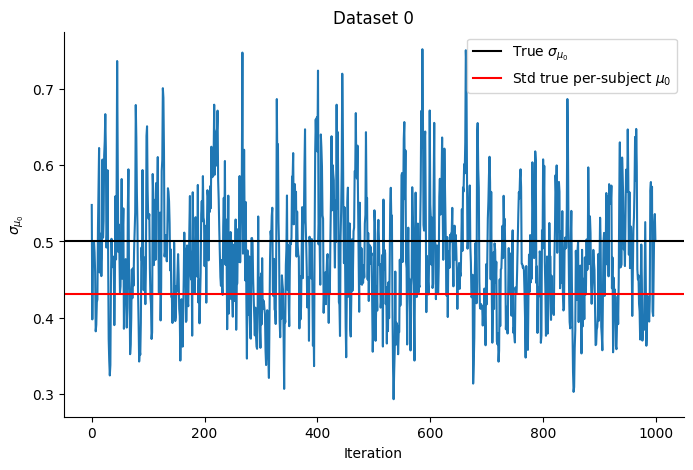

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(posterior_samples_sigma_mu_x[dataset][burn_in:])
plt.axhline(true_sigma_mu_x, color='black', label=r"True $\sigma_{\mu_0}$")
plt.axhline(jnp.std(all_true_params[dataset]['mu_x']), color='red', label="Std true per-subject $\mu_0$")
plt.xlabel("Iteration")
plt.ylabel(r"$\sigma_{\mu_0}$")
plt.legend(loc='upper right')
plt.title(r"Dataset {:d}".format(dataset))
sns.despine()
plt.show()

In [131]:
def within_95_ci(posterior_samples,
                 true_param,
                 w_true=False,
                 variable_index=0): # indicate which w
    
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:]
        if w_true: # to bypass different data formatting for mu_w and sigma_w
            posterior = posterior_samples[dataset][burn_in:,variable_index]
            
        if jnp.percentile(posterior, 2.5) < true_param < jnp.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)



In [132]:
mu_sigmasq = within_95_ci(posterior_samples_mu_sigmasq, true_mu_sigmasq)
print("mu_sigmasq", mu_sigmasq, "/", num_datasets)

beta_sigmasq = within_95_ci(posterior_samples_beta_sigmasq, true_beta_sigmasq)
print("beta_sigmasq:", beta_sigmasq, "/", num_datasets)

mu_a = within_95_ci(posterior_samples_mu_a, true_mu_a)
print("mu_a:", mu_a, "/", num_datasets)

sigma_a = within_95_ci(posterior_samples_sigma_a, true_sigma_a)
print("sigma_a:", sigma_a, "/", num_datasets)

sigma_mu_x = within_95_ci(posterior_samples_sigma_mu_x, true_sigma_mu_x)
print("sigma_mu_x:", sigma_mu_x, "/", num_datasets)

w0 = within_95_ci(posterior_samples_mu_w, true_mu_w[0], w_true=True, variable_index=0)
print("w0:", w0, "/", num_datasets)

w1 = within_95_ci(posterior_samples_mu_w, true_mu_w[1], w_true=True, variable_index=1)
print("w1:", w1, "/", num_datasets)

w2 = within_95_ci(posterior_samples_mu_w, true_mu_w[2], w_true=True, variable_index=2)
print("w2:", w2, "/", num_datasets)

sigma_w0 = within_95_ci(posterior_samples_sigma_w, true_sigma_w[0], w_true=True, variable_index=0)
print("sigma_w0:", sigma_w0, "/", num_datasets)

sigma_w1 = within_95_ci(posterior_samples_sigma_w, true_sigma_w[1], w_true=True, variable_index=1)
print("sigma_w1:", sigma_w1, "/", num_datasets)

sigma_w2 = within_95_ci(posterior_samples_sigma_w, true_sigma_w[2], w_true=True, variable_index=2)
print("sigma_w2:", sigma_w2, "/", num_datasets)


mu_sigmasq 20 / 20
beta_sigmasq: 14 / 20
mu_a: 19 / 20
sigma_a: 18 / 20
sigma_mu_x: 19 / 20
w0: 20 / 20
w1: 20 / 20
w2: 18 / 20
sigma_w0: 18 / 20
sigma_w1: 20 / 20
sigma_w2: 19 / 20


In [133]:
import numpy as np
def within_95_ci_subject_w(posterior_samples,
                           variable_index=0,
                           mean=True): # if False then true value is standard deviation of per-subject true w's
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:,variable_index]
        true_value = jnp.std(all_true_params[dataset]['w'][:,variable_index])
        if mean:
            true_value = jnp.mean(all_true_params[dataset]['w'][:,variable_index])
                
        if np.percentile(posterior, 2.5) < true_value < np.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)



def within_95_ci_subject_a(posterior_samples,
                           mean=True): # if False then true value is standard deviation of per-subject true a's
    
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:]
        true_value = jnp.std(all_true_params[dataset]['a'])
        if mean:
            true_value = jnp.mean(all_true_params[dataset]['a'])
                
        if np.percentile(posterior, 2.5) < true_value < np.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)



def within_95_ci_subject_mu(posterior_samples,
                           mean=True): # if False then true value is standard deviation of per-subject true a's
    
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:]
        true_value = jnp.std(all_true_params[dataset]['mu_x'])
        if mean:
            true_value = jnp.mean(all_true_params[dataset]['mu_x'])
                
        if np.percentile(posterior, 2.5) < true_value < np.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)


def within_95_ci_subject_mu_sigmasq(posterior_samples,
                           mean=True): # if False then true value is standard deviation of per-subject true a's
    
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:]
        true_value = jnp.std(all_true_params[dataset]['sigmasq'])
        if mean:
            true_value = jnp.mean(all_true_params[dataset]['sigmasq'])
                
        if np.percentile(posterior, 2.5) < true_value < np.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)

mu_sigmasq_subject = within_95_ci_subject_mu_sigmasq(posterior_samples_mu_sigmasq)
print("mu_sigmasq_subject:", mu_sigmasq_subject, "/", num_datasets)
mu_a_subject = within_95_ci_subject_a(posterior_samples_mu_a)
print("mu_a_subject:", mu_a_subject, "/", num_datasets)
sigma_a_subject = within_95_ci_subject_a(posterior_samples_sigma_a, mean=False)
print("sigma_a_subject:", sigma_a_subject, "/", num_datasets)
sigma_mu_x_subject = within_95_ci_subject_mu(posterior_samples_sigma_mu_x, mean=False)
print("sigma_mu_x_subject:", sigma_mu_x_subject, "/", num_datasets)
w0_subject = within_95_ci_subject_w(posterior_samples_mu_w, variable_index=0)
print("w0_subject:", w0_subject, "/", num_datasets)
w1_subject = within_95_ci_subject_w(posterior_samples_mu_w, variable_index=1)
print("w1_subject:", w1_subject, "/", num_datasets)
w2_subject = within_95_ci_subject_w(posterior_samples_mu_w, variable_index=2)
print("w2_subject:", w2_subject, "/", num_datasets)
sigma_w0_subject = within_95_ci_subject_w(posterior_samples_sigma_w, variable_index=0, mean=False)
print("sigma_w0_subject:", sigma_w0_subject, "/", num_datasets)
sigma_w1_subject = within_95_ci_subject_w(posterior_samples_sigma_w, variable_index=1, mean=False)
print("sigma_w1_subject:", sigma_w1_subject, "/", num_datasets)
sigma_w2_subject = within_95_ci_subject_w(posterior_samples_sigma_w, variable_index=2, mean=False)
print("sigma_w2_subject:", sigma_w2_subject, "/", num_datasets)



mu_sigmasq_subject: 17 / 20
mu_a_subject: 15 / 20
sigma_a_subject: 18 / 20
sigma_mu_x_subject: 19 / 20
w0_subject: 20 / 20
w1_subject: 20 / 20
w2_subject: 20 / 20
sigma_w0_subject: 20 / 20
sigma_w1_subject: 20 / 20
sigma_w2_subject: 20 / 20
